<a href="https://colab.research.google.com/github/vishalmmca25-design/ml-and-datavisualization/blob/main/lab1_matplotlib_basics_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 1. Setup and dataset

Import the libraries. If an import fails, install it with
`pip install matplotlib numpy pandas scikit-learn`.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("NumPy      :", np.__version__)
print("pandas     :", pd.__version__)
print("Matplotlib :", matplotlib.__version__)

%matplotlib inline
print("\nSetup complete.")

NumPy      : 2.0.2
pandas     : 2.2.2
Matplotlib : 3.10.0

Setup complete.


In [ ]:
# Load the Iris dataset (no internet needed)
from sklearn.datasets import load_iris

data = load_iris()
iris = pd.DataFrame(data.data, columns=["sepal_length", "sepal_width",
                                        "petal_length", "petal_width"])
iris["species"] = data.target_names[data.target]

print("Shape:", iris.shape)
print("\nFirst 5 rows:")
print(iris.head())
print("\nCount of each species:")
print(iris["species"].value_counts())

Shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Count of each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---
## 2. Your first plot

Two steps are needed for every Matplotlib plot:

1. `fig, ax = plt.subplots()` creates a **figure** (the whole picture) and an
   **axes** (one plotting area inside it).
2. `ax.plot(x, y)` draws the data.

Finally `plt.show()` displays the result.

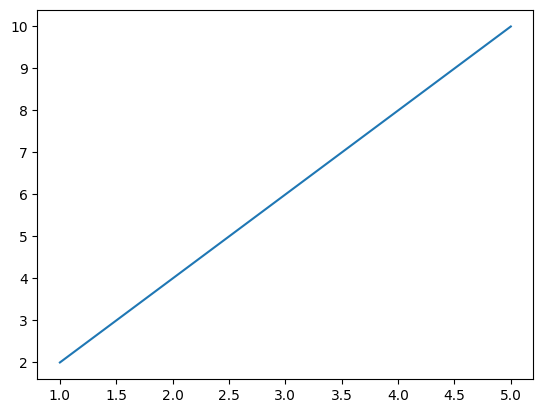

In [ ]:
# A simple line plot
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()

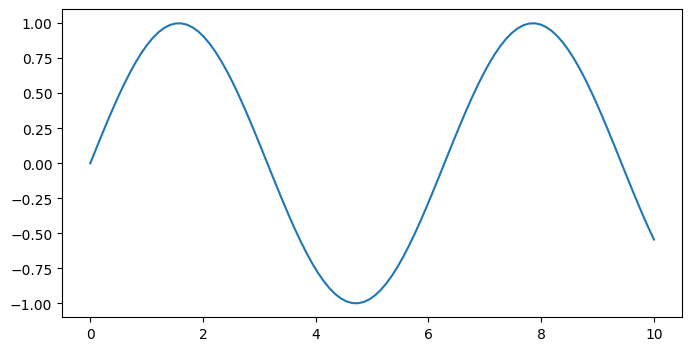

np.linspace(0, 10, 100) gives 100 points between 0 and 10.


In [ ]:
# figsize controls the size of the figure, in inches (width, height)
x = np.linspace(0, 10, 100)     # 100 evenly spaced numbers from 0 to 10
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y)
plt.show()

print("np.linspace(0, 10, 100) gives 100 points between 0 and 10.")

---
## 3. Labels, title, legend and grid

A plot without labels cannot be understood. Always add:

| Command | Purpose |
|---|---|
| `ax.set_xlabel("...")` | name of the X axis |
| `ax.set_ylabel("...")` | name of the Y axis |
| `ax.set_title("...")` | title of the plot |
| `ax.legend()` | box naming each line (needs `label=` in `plot`) |
| `ax.grid(True)` | background grid lines |

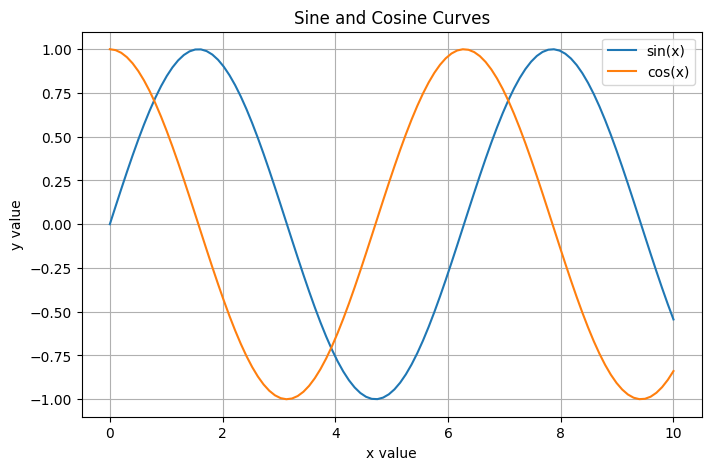

In [ ]:
# The same plot, now fully labelled
x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")

ax.set_xlabel("x value")
ax.set_ylabel("y value")
ax.set_title("Sine and Cosine Curves")
ax.legend()
ax.grid(True)

plt.show()

---
## 4. Colours, line styles and markers

The three arguments used most often in `ax.plot()`:

| Argument | Meaning | Examples |
|---|---|---|
| `color` | line colour | `'red'`, `'green'`, `'blue'`, `'#2E86AB'` |
| `linestyle` | pattern of the line | `'-'` solid, `'--'` dashed, `'-.'` dash-dot, `':'` dotted |
| `marker` | symbol on each point | `'o'` circle, `'s'` square, `'^'` triangle, `'*'` star |

Two more that are often useful: `linewidth` (thickness) and `label` (for the legend).

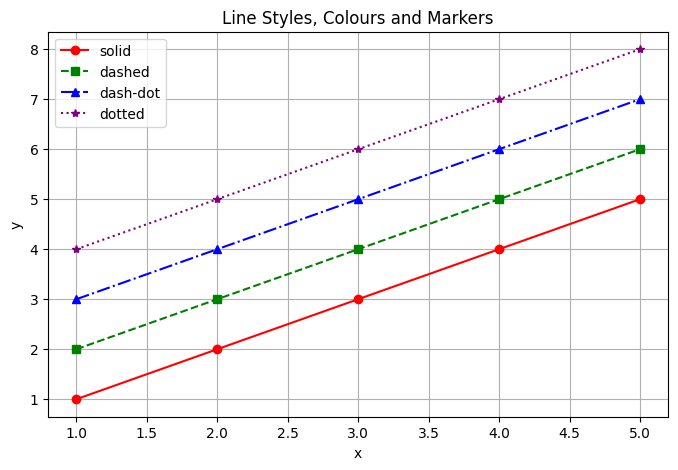

In [ ]:
# Four different line styles
x = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, [1, 2, 3, 4, 5],  color="red",   linestyle="-",  marker="o", label="solid")
ax.plot(x, [2, 3, 4, 5, 6],  color="green", linestyle="--", marker="s", label="dashed")
ax.plot(x, [3, 4, 5, 6, 7],  color="blue",  linestyle="-.", marker="^", label="dash-dot")
ax.plot(x, [4, 5, 6, 7, 8],  color="purple", linestyle=":", marker="*", label="dotted")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Line Styles, Colours and Markers")
ax.legend()
ax.grid(True)
plt.show()

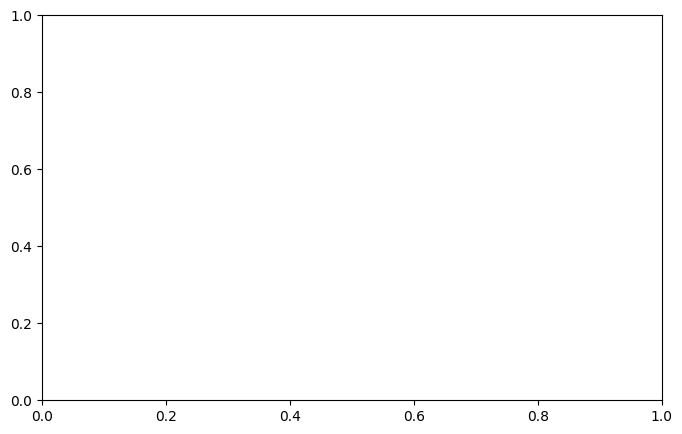

In [ ]:
# TRY IT
# Plot y = x and y = x*x for x = [1, 2, 3, 4, 5] on one axes.
# Use a different colour and marker for each line.
# Add x label, y label, a title, a legend and a grid.

x = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(8, 5))

# --- write your code below ---


plt.show()

---
## 5. Scatter plot

`ax.scatter(x, y)` draws one point per observation. It is used to check whether
two variables are related.

Useful arguments: `color`, `s` (size of the points), `alpha` (transparency,
0 to 1), `label`.

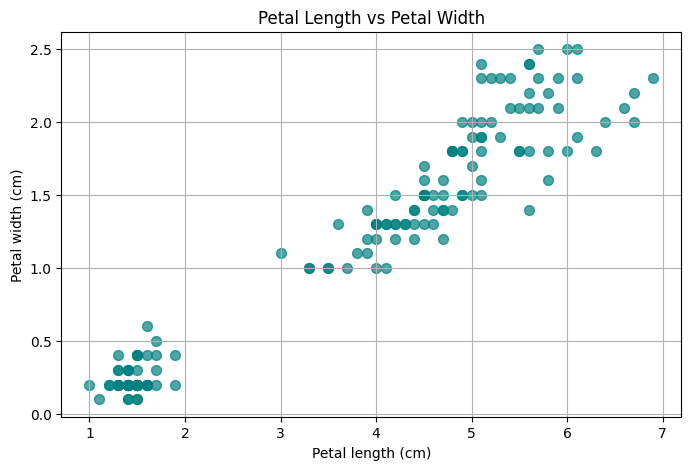

The points rise from left to right, so the two variables increase together.


In [ ]:
# Scatter plot: is petal length related to petal width?
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(iris["petal_length"], iris["petal_width"], color="teal", s=50, alpha=0.7)

ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Petal Length vs Petal Width")
ax.grid(True)
plt.show()

print("The points rise from left to right, so the two variables increase together.")

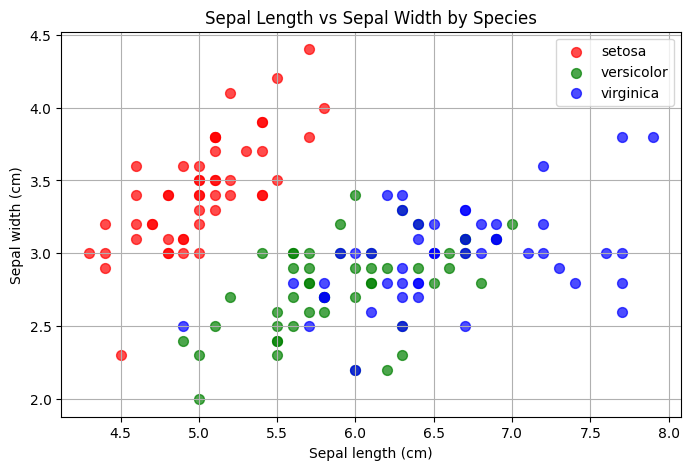

In [ ]:
# One colour per species: draw one scatter for each group
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"setosa": "red", "versicolor": "green", "virginica": "blue"}

for name in ["setosa", "versicolor", "virginica"]:
    group = iris[iris["species"] == name]          # select the rows of one species
    ax.scatter(group["sepal_length"], group["sepal_width"],
               color=colors[name], s=50, alpha=0.7, label=name)

ax.set_xlabel("Sepal length (cm)")
ax.set_ylabel("Sepal width (cm)")
ax.set_title("Sepal Length vs Sepal Width by Species")
ax.legend()
ax.grid(True)
plt.show()

---
## 6. Bar chart

`ax.bar(categories, values)` draws vertical bars and is used to compare a value
across categories. `ax.barh()` draws horizontal bars.

Here we compare the **average** petal length of the three species.

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64


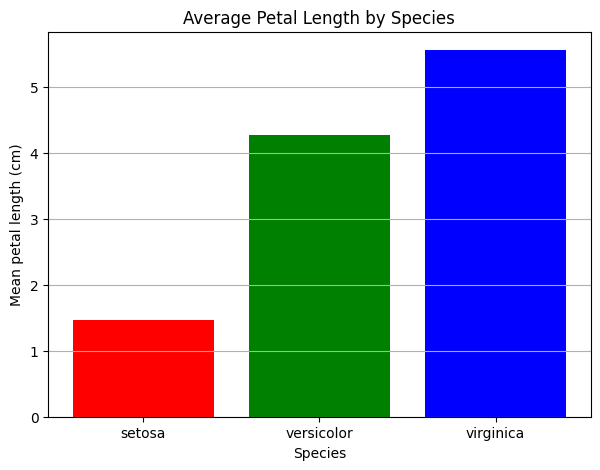

In [ ]:
# Average petal length of each species
means = iris.groupby("species")["petal_length"].mean()
print(means)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(means.index, means.values, color=["red", "green", "blue"])

ax.set_xlabel("Species")
ax.set_ylabel("Mean petal length (cm)")
ax.set_title("Average Petal Length by Species")
ax.grid(True, axis="y")
plt.show()

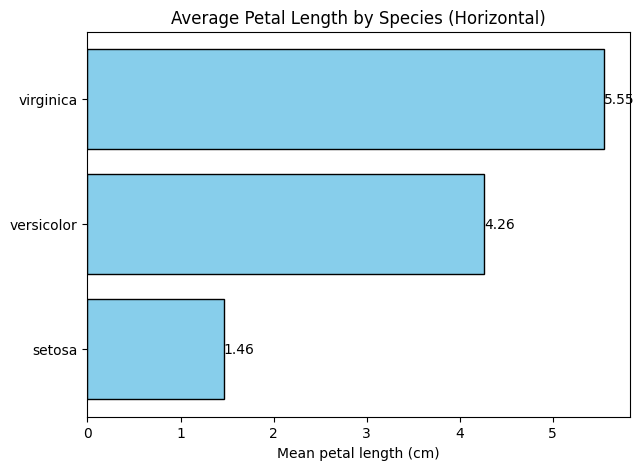

In [ ]:
# Horizontal bars, with the value written on each bar
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(means.index, means.values, color="skyblue", edgecolor="black")

ax.bar_label(bars, fmt="%.2f")          # writes the number at the end of each bar
ax.set_xlabel("Mean petal length (cm)")
ax.set_title("Average Petal Length by Species (Horizontal)")
plt.show()

---
## 7. Histogram

`ax.hist(data, bins=n)` splits one numeric column into `n` intervals (bins) and
counts how many values fall in each. It shows the **shape** of the data.

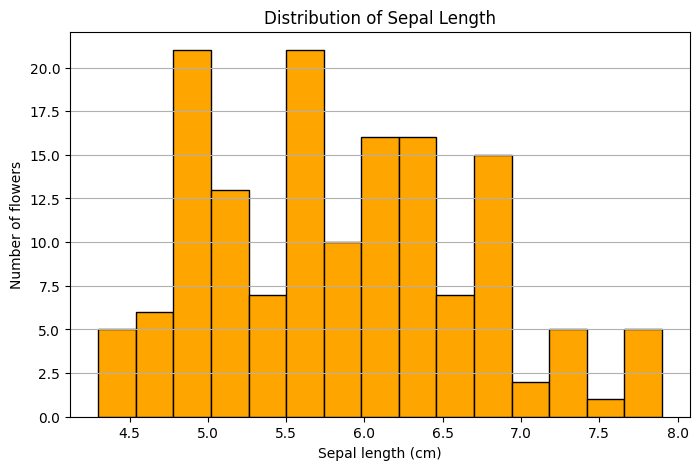

Mean   : 5.84
Median : 5.8


In [ ]:
# Histogram of sepal length
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(iris["sepal_length"], bins=15, color="orange", edgecolor="black")

ax.set_xlabel("Sepal length (cm)")
ax.set_ylabel("Number of flowers")
ax.set_title("Distribution of Sepal Length")
ax.grid(True, axis="y")
plt.show()

print("Mean   :", round(iris["sepal_length"].mean(), 2))
print("Median :", round(iris["sepal_length"].median(), 2))

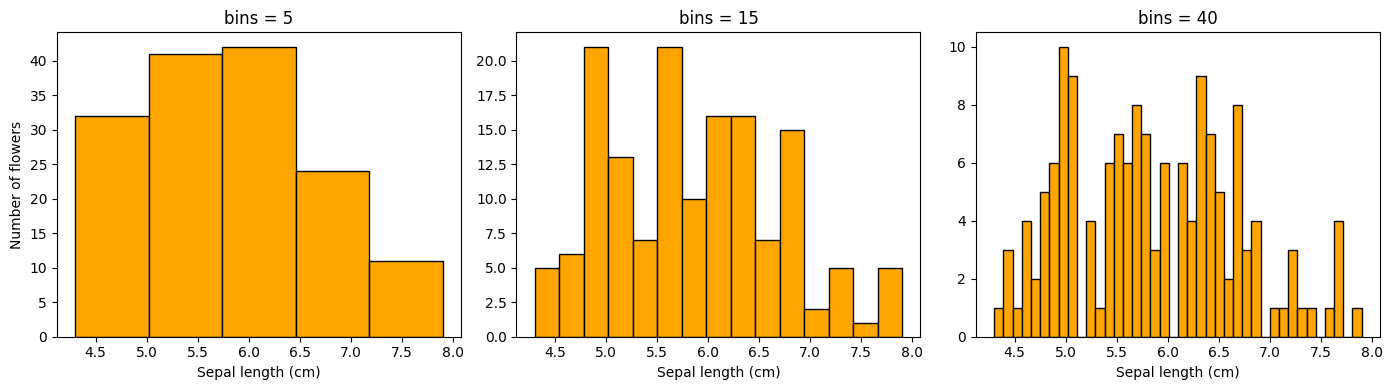

Too few bins hides the shape; too many makes it look like noise.


In [ ]:
# Changing 'bins' changes how much detail you see
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, b in zip(axes, [5, 15, 40]):
    ax.hist(iris["sepal_length"], bins=b, color="orange", edgecolor="black")
    ax.set_title("bins = " + str(b))
    ax.set_xlabel("Sepal length (cm)")

axes[0].set_ylabel("Number of flowers")
plt.tight_layout()
plt.show()

print("Too few bins hides the shape; too many makes it look like noise.")

---
## 8. Box plot

`ax.boxplot(data)` summarises a distribution using five numbers: the minimum,
the lower quartile (Q1), the median, the upper quartile (Q3) and the maximum.
Points drawn beyond the whiskers are possible outliers.

> **Note:** in recent Matplotlib versions the argument for the category names is
> `tick_labels=` (it used to be `labels=`).

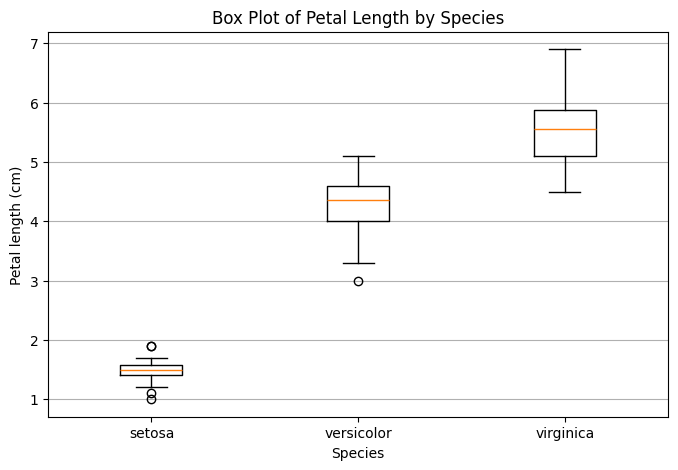

The box covers the middle 50% of the data and the line inside is the median.


In [ ]:
# Box plot of petal length for the three species
groups = [iris[iris["species"] == name]["petal_length"]
          for name in ["setosa", "versicolor", "virginica"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, tick_labels=["setosa", "versicolor", "virginica"])

ax.set_xlabel("Species")
ax.set_ylabel("Petal length (cm)")
ax.set_title("Box Plot of Petal Length by Species")
ax.grid(True, axis="y")
plt.show()

print("The box covers the middle 50% of the data and the line inside is the median.")

---
## 9. Pie chart

`ax.pie(values, labels=names)` shows how a total is divided into parts.
`autopct="%1.1f%%"` prints the percentage on each slice.

Use a pie chart only when the parts add up to one whole and there are few categories.

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


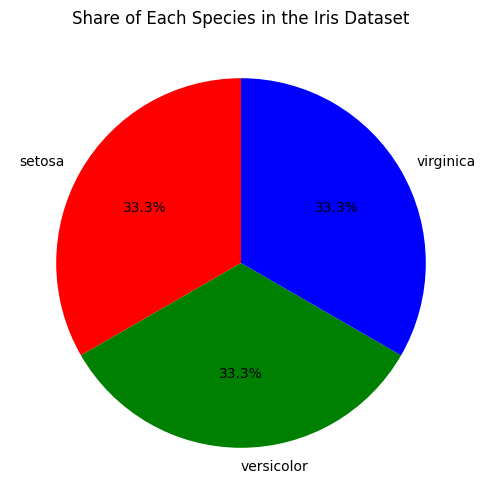

In [ ]:
# Pie chart of the number of flowers of each species
counts = iris["species"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
       colors=["red", "green", "blue"], startangle=90)

ax.set_title("Share of Each Species in the Iris Dataset")
plt.show()

---
## 10. Multiple plots in one figure

`plt.subplots(rows, cols)` returns a grid of axes.

* With one row, use `axes[0]`, `axes[1]`, ...
* With several rows and columns, use `axes[row][col]`.

`plt.tight_layout()` adds spacing so the labels do not overlap.

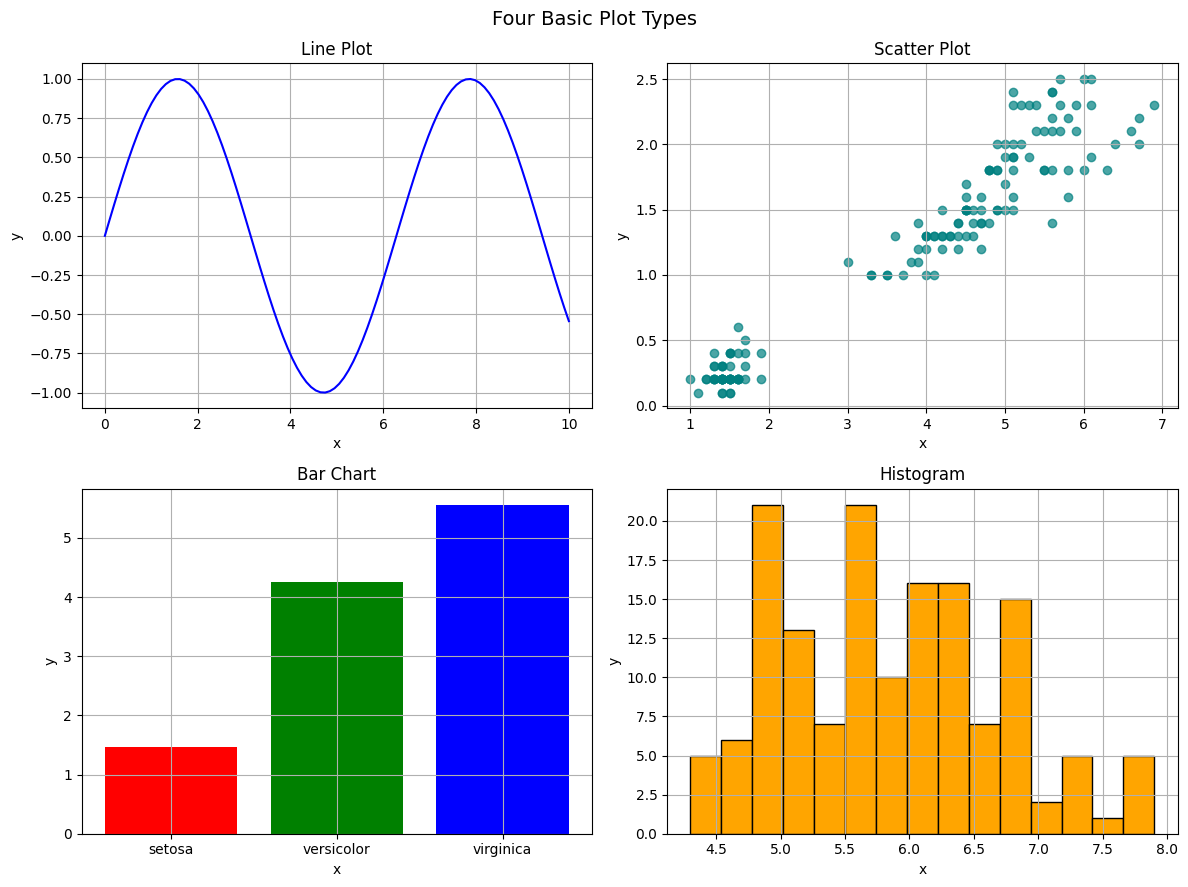

In [ ]:
# A 2 x 2 grid of four different plot types
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# top-left : line plot
x = np.linspace(0, 10, 100)
axes[0][0].plot(x, np.sin(x), color="blue")
axes[0][0].set_title("Line Plot")

# top-right : scatter plot
axes[0][1].scatter(iris["petal_length"], iris["petal_width"], color="teal", alpha=0.7)
axes[0][1].set_title("Scatter Plot")

# bottom-left : bar chart
axes[1][0].bar(means.index, means.values, color=["red", "green", "blue"])
axes[1][0].set_title("Bar Chart")

# bottom-right : histogram
axes[1][1].hist(iris["sepal_length"], bins=15, color="orange", edgecolor="black")
axes[1][1].set_title("Histogram")

# label every panel and add a grid
for row in axes:
    for ax in row:
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(True)

fig.suptitle("Four Basic Plot Types", fontsize=14)
plt.tight_layout()
plt.show()

---
## 11. Saving a figure

`fig.savefig("name.png")` writes the figure to a file in the current folder.

* `dpi=300` gives a high-quality image suitable for a report.
* `bbox_inches="tight"` makes sure no label is cut off.

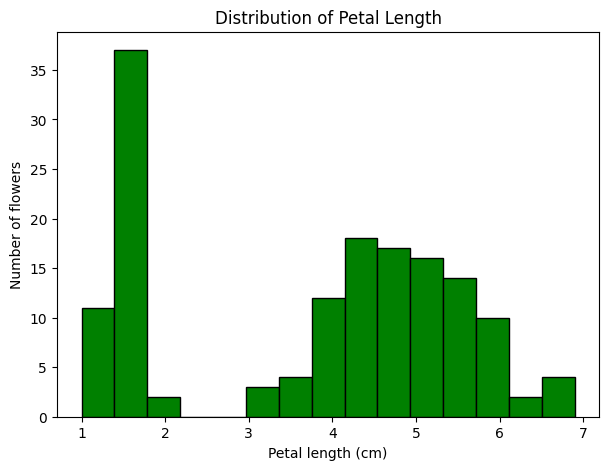

File created: True
Size: 60.7 KB


In [ ]:
# Create a plot and save it as an image
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(iris["petal_length"], bins=15, color="green", edgecolor="black")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Number of flowers")
ax.set_title("Distribution of Petal Length")

fig.savefig("my_plot.png", dpi=300, bbox_inches="tight")
plt.show()

import os
print("File created:", os.path.exists("my_plot.png"))
print("Size:", round(os.path.getsize("my_plot.png") / 1024, 1), "KB")